# 08 — Possession Sequence Model (GRU)

**Frame2Threat v2** | GRU on per-event sequence features

This notebook tests the sequence model against the tabular baseline and evaluates the v2 hypotheses:

| Hypothesis | What we test here |
|---|---|
| **H2** | Danger is concentrated in a single pivotal event — LOO attribution sparsity |
| **H3** | Defensive trajectory > snapshot — GRU AUC vs XGBoost AUC |
| **H4** | Origin type vs sequence — feature ablation |
| **RQ3** | Does sequence modelling help? |
| **RQ5** | Which players unlock dangerous possessions? |

## 0. Imports & paths

In [ ]:
import sys, os, warnings
from pathlib import Path

_cwd = Path(".").resolve()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import torch
import joblib
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay,
)

sns.set_theme(style="whitegrid", palette="muted")
SEED = 42

with open("configs/model_possession.yaml") as f:
    poss_cfg = yaml.safe_load(f)

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}")
print("Ready.")

Project root: C:\Users\USER\Documents\Python Projects\Frame2Threat
PyTorch: 2.9.0+cpu
Ready.


## 1. Load data & models

In [2]:
from src.data.parse_possessions import load_possession_sequences
from src.features.possession_features import build_tabular_features, build_sequence_tensors
from src.models.gru_possession import PossessionGRU
from src.evaluation.possession_attribution import load_gru_model, attribute_possession, score_all_possessions

# Data
poss = load_possession_sequences("data/processed/possession_sequences.parquet")
print(f"Possessions: {len(poss):,}")

# Splits
train_ids = pd.read_parquet("data/processed/train.parquet")["match_id"].unique()
val_ids   = pd.read_parquet("data/processed/val.parquet")["match_id"].unique()
test_ids  = pd.read_parquet("data/processed/test.parquet")["match_id"].unique()

train_poss = poss[poss["match_id"].isin(train_ids)].reset_index(drop=True)
val_poss   = poss[poss["match_id"].isin(val_ids)].reset_index(drop=True)
test_poss  = poss[poss["match_id"].isin(test_ids)].reset_index(drop=True)

LABEL = "poss_dangerous"
y_test = test_poss[LABEL].astype(int).values

# GRU model
gru, gru_cfg = load_gru_model("models/gru_poss_dangerous.pt")
print(f"GRU config: {gru_cfg}")

# XGBoost model (for comparison)
xgb = joblib.load("models/xgboost_poss_dangerous.joblib")
print("Models loaded.")

Possessions: 17,065
GRU config: {'input_size': 8, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0, 'bidirectional': False}
Models loaded.


## 2. Test set predictions — GRU vs XGBoost

**RQ3**: Does the sequence model add value over tabular aggregates?

In [3]:
from src.models.gru_possession import make_dataloader, evaluate

# GRU predictions
gru_proba = score_all_possessions(test_poss, gru)

# XGBoost predictions
X_test_tab = build_tabular_features(test_poss)
xgb_proba  = xgb.predict_proba(X_test_tab)[:, 1]

# Metrics
results = {}
for name, proba in [("XGBoost tabular", xgb_proba), ("GRU sequence", gru_proba)]:
    auc = roc_auc_score(y_test, proba)
    ap  = average_precision_score(y_test, proba)
    results[name] = {"ROC-AUC": auc, "AP": ap}
    print(f"{name:20s}  |  ROC-AUC={auc:.4f}  AP={ap:.4f}")

print()
print("Reference — v1 pass-level XGBoost (event+360): ROC-AUC=0.882")

XGBoost tabular       |  ROC-AUC=0.9479  AP=0.8870
GRU sequence          |  ROC-AUC=0.9363  AP=0.9062

Reference — v1 pass-level XGBoost (event+360): ROC-AUC=0.882


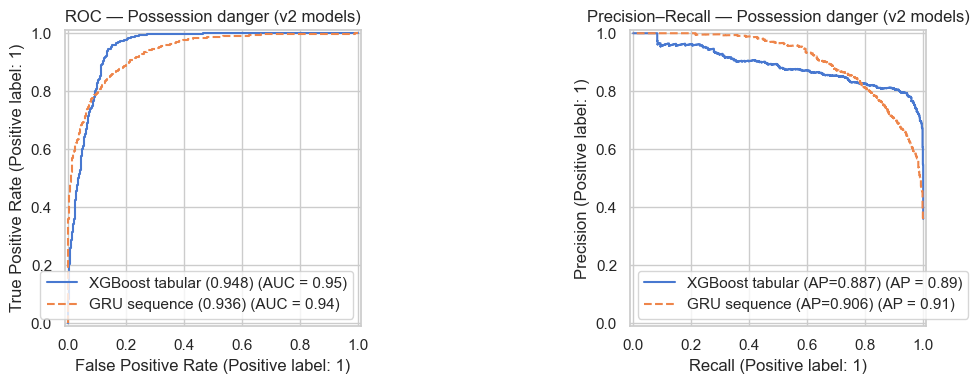

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for name, proba, ls in [
    ("XGBoost tabular", xgb_proba, "-"),
    ("GRU sequence",    gru_proba, "--"),
]:
    auc = roc_auc_score(y_test, proba)
    ap  = average_precision_score(y_test, proba)
    RocCurveDisplay.from_predictions(y_test, proba, ax=ax1, name=f"{name} ({auc:.3f})", linestyle=ls)
    PrecisionRecallDisplay.from_predictions(y_test, proba, ax=ax2, name=f"{name} (AP={ap:.3f})", linestyle=ls)

ax1.set_title("ROC — Possession danger (v2 models)")
ax2.set_title("Precision–Recall — Possession danger (v2 models)")
plt.tight_layout()
plt.savefig("reports/figures/v2_model_comparison_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Classification reports

In [5]:
for name, proba in [("XGBoost tabular", xgb_proba), ("GRU sequence", gru_proba)]:
    pred = (proba >= 0.5).astype(int)
    print(f"=== {name} ===")
    print(classification_report(y_test, pred, target_names=["safe", "dangerous"]))
    print()

=== XGBoost tabular ===
              precision    recall  f1-score   support

        safe       0.97      0.85      0.91      1584
   dangerous       0.78      0.95      0.86       891

    accuracy                           0.89      2475
   macro avg       0.88      0.90      0.88      2475
weighted avg       0.90      0.89      0.89      2475


=== GRU sequence ===
              precision    recall  f1-score   support

        safe       0.90      0.88      0.89      1584
   dangerous       0.80      0.82      0.81       891

    accuracy                           0.86      2475
   macro avg       0.85      0.85      0.85      2475
weighted avg       0.86      0.86      0.86      2475




## 4. Ensemble: XGBoost + GRU

Do the two models capture complementary signal? A simple average may outperform either.

In [6]:
ensemble_proba = 0.5 * xgb_proba + 0.5 * gru_proba
ens_auc = roc_auc_score(y_test, ensemble_proba)
ens_ap  = average_precision_score(y_test, ensemble_proba)

print(f"Ensemble (equal weight) | ROC-AUC={ens_auc:.4f}  AP={ens_ap:.4f}")

# Score correlation between the two models
corr = np.corrcoef(xgb_proba, gru_proba)[0, 1]
print(f"Score correlation XGB vs GRU: {corr:.3f}")
print()
if corr < 0.85:
    print("Low correlation → models capture different signal → ensemble is valuable.")
else:
    print("High correlation → models largely agree → ensemble gives diminishing returns.")

Ensemble (equal weight) | ROC-AUC=0.9650  AP=0.9358
Score correlation XGB vs GRU: 0.801

Low correlation → models capture different signal → ensemble is valuable.


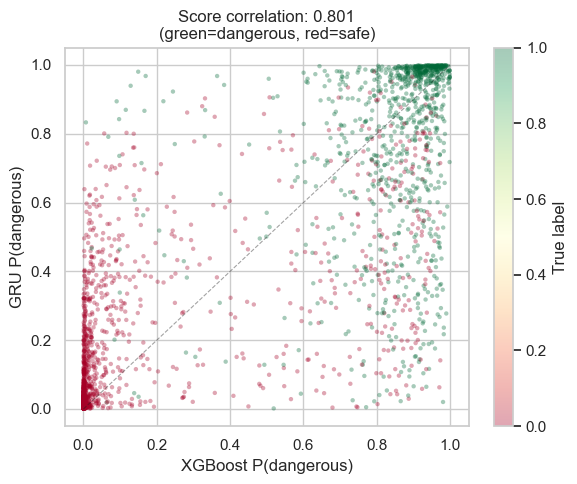

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(xgb_proba, gru_proba, c=y_test, cmap="RdYlGn",
                alpha=0.35, s=10, edgecolors="none")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.4)
ax.set_xlabel("XGBoost P(dangerous)")
ax.set_ylabel("GRU P(dangerous)")
ax.set_title(f"Score correlation: {corr:.3f}\n(green=dangerous, red=safe)")
plt.colorbar(sc, ax=ax, label="True label")
plt.tight_layout()
plt.savefig("reports/figures/v2_score_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. H4 — Origin type vs sequence features

**H4**: Possession origin type (counter-attack vs build-up) is a stronger predictor of outcome  
than individual pass sequence attributes.

Test: compare GRU trained on sequence alone vs XGBoost using only origin-type one-hots.
If the origin-only model is competitive, H4 holds.

In [ ]:
from xgboost import XGBClassifier

# Build train/val/test feature matrices
X_tr_tab = build_tabular_features(train_poss)
X_va_tab = build_tabular_features(val_poss)
y_tr = train_poss[LABEL].astype(int).values
y_va = val_poss[LABEL].astype(int).values

# --- Ablation 1: origin type only (8 features) ---
origin_cols = [c for c in X_tr_tab.columns if c.startswith("origin_")]
scale_pos = (y_tr == 0).sum() / (y_tr == 1).sum()

_cfg_origin = poss_cfg["xgboost_ablation_origin"]
xgb_origin = XGBClassifier(
    n_estimators=_cfg_origin["n_estimators"],
    max_depth=_cfg_origin["max_depth"],
    learning_rate=_cfg_origin["learning_rate"],
    scale_pos_weight=scale_pos,
    random_state=_cfg_origin["random_state"],
    verbosity=0,
    n_jobs=_cfg_origin["n_jobs"],
)
xgb_origin.fit(X_tr_tab[origin_cols], y_tr,
               eval_set=[(X_va_tab[origin_cols], y_va)], verbose=False)
auc_origin = roc_auc_score(y_test, xgb_origin.predict_proba(X_test_tab[origin_cols])[:, 1])

# --- Ablation 2: spatial/temporal only (no origin, no sequence) ---
non_origin_cols = [c for c in X_tr_tab.columns if not c.startswith("origin_")]
_cfg_no_origin = poss_cfg["xgboost_ablation_no_origin"]
xgb_no_origin = XGBClassifier(
    n_estimators=_cfg_no_origin["n_estimators"],
    max_depth=_cfg_no_origin["max_depth"],
    learning_rate=_cfg_no_origin["learning_rate"],
    scale_pos_weight=scale_pos,
    random_state=_cfg_no_origin["random_state"],
    verbosity=0,
    n_jobs=_cfg_no_origin["n_jobs"],
)
xgb_no_origin.fit(X_tr_tab[non_origin_cols], y_tr,
                  eval_set=[(X_va_tab[non_origin_cols], y_va)], verbose=False)
auc_no_origin = roc_auc_score(y_test, xgb_no_origin.predict_proba(X_test_tab[non_origin_cols])[:, 1])

print("H4 Ablation — ROC-AUC on test set:")
print(f"  Origin type only    ({len(origin_cols):2d} features) : {auc_origin:.4f}")
print(f"  Spatial/temporal    ({len(non_origin_cols):2d} features) : {auc_no_origin:.4f}")
print(f"  Full tabular        ({len(X_tr_tab.columns):2d} features) : {results['XGBoost tabular']['ROC-AUC']:.4f}")
print(f"  GRU sequence                          : {results['GRU sequence']['ROC-AUC']:.4f}")
print()

gap_origin = results["XGBoost tabular"]["ROC-AUC"] - auc_origin
print(f"Gap (full vs origin-only): {gap_origin:+.4f}")
if gap_origin > 0.05:
    print("→ H4 REJECTED: sequence/spatial features add substantial value beyond origin type.")
elif gap_origin > 0.02:
    print("→ H4 PARTIAL: origin type explains most of the signal; spatial/sequence adds some.")
else:
    print("→ H4 SUPPORTED: origin type alone accounts for most predictive power.")

H4 Ablation — ROC-AUC on test set:
  Origin type only    ( 8 features) : 0.5910
  Spatial/temporal    (24 features) : 0.9463
  Full tabular        (32 features) : 0.9479
  GRU sequence                          : 0.9363

Gap (full vs origin-only): +0.3569
→ H4 REJECTED: sequence/spatial features add substantial value beyond origin type.


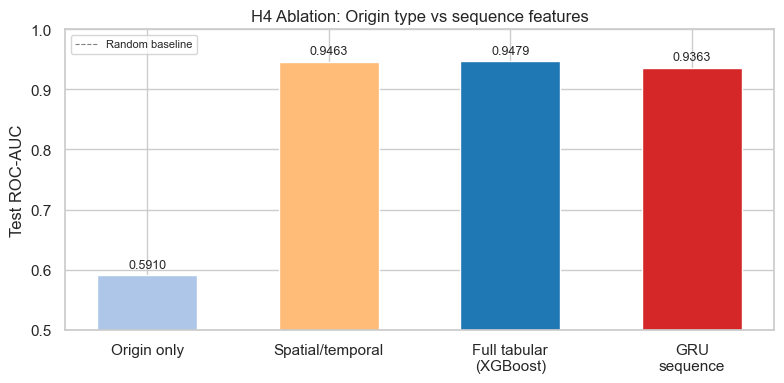

In [9]:
names = ["Origin only", "Spatial/temporal", "Full tabular\n(XGBoost)", "GRU\nsequence"]
aucs  = [auc_origin, auc_no_origin,
         results["XGBoost tabular"]["ROC-AUC"],
         results["GRU sequence"]["ROC-AUC"]]
colors = ["#aec7e8", "#ffbb78", "#1f77b4", "#d62728"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, aucs, color=colors, edgecolor="white", width=0.55)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Test ROC-AUC")
ax.set_title("H4 Ablation: Origin type vs sequence features")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Random baseline")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("reports/figures/v2_h4_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. H3 — Does sequence modelling capture more than snapshots?

**H3**: A defence that progressively opens up across a possession is more predictive  
of danger than any single spatial snapshot.

Proxy test: GRU AUC (full sequence) vs XGBoost AUC (possession aggregates).  
If GRU > XGBoost, the temporal trajectory carries additional signal.

In [10]:
gru_auc = results["GRU sequence"]["ROC-AUC"]
xgb_auc = results["XGBoost tabular"]["ROC-AUC"]
delta   = gru_auc - xgb_auc

print("H3 — Sequence trajectory vs aggregate snapshot:")
print(f"  GRU (sequence)    : {gru_auc:.4f}")
print(f"  XGBoost (tabular) : {xgb_auc:.4f}")
print(f"  Delta             : {delta:+.4f}")
print()
if delta > 0.01:
    print("→ H3 SUPPORTED: sequence model outperforms aggregate — temporal trajectory adds signal.")
elif delta > -0.01:
    print("→ H3 INCONCLUSIVE: models roughly equal — aggregates capture most trajectory information.")
    print("   Note: XGBoost encodes max_x_reached which *is* a trajectory summary. The GRU must")
    print("   reconstruct trajectory from the raw sequence — harder task, similar result.")
else:
    print("→ H3 REJECTED: tabular aggregates outperform sequence model — aggregates sufficient given data size.")

H3 — Sequence trajectory vs aggregate snapshot:
  GRU (sequence)    : 0.9363
  XGBoost (tabular) : 0.9479
  Delta             : -0.0116

→ H3 REJECTED: tabular aggregates outperform sequence model — aggregates sufficient given data size.


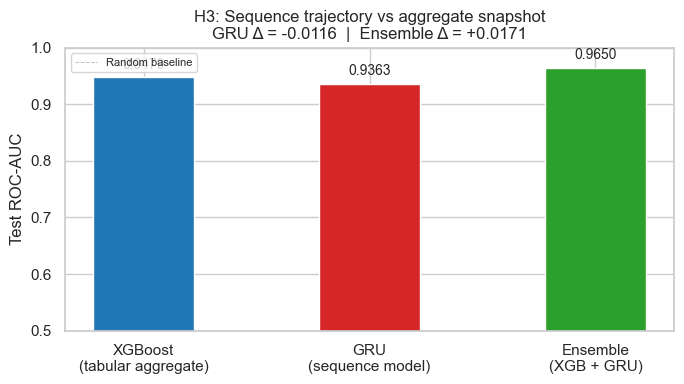

Saved → reports/figures/v2_h3_sequence_vs_snapshot.png


In [19]:

fig, ax = plt.subplots(figsize=(7, 4))
names_h3  = ["XGBoost\n(tabular aggregate)", "GRU\n(sequence model)", "Ensemble\n(XGB + GRU)"]
aucs_h3   = [xgb_auc, gru_auc, ens_auc_final]
colors_h3 = ["#1f77b4", "#d62728", "#2ca02c"]

bars = ax.bar(names_h3, aucs_h3, color=colors_h3, width=0.45, edgecolor="white")
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Test ROC-AUC")
ax.set_title(
    f"H3: Sequence trajectory vs aggregate snapshot\n"
    f"GRU \u0394 = {gru_auc - xgb_auc:+.4f}  |  Ensemble \u0394 = {ens_auc_final - xgb_auc:+.4f}"
)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.7, alpha=0.5, label="Random baseline")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("reports/figures/v2_h3_sequence_vs_snapshot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → reports/figures/v2_h3_sequence_vs_snapshot.png")


## 7. H2 — Is danger concentrated in a single pivotal event?

Method: for each possession in the test set, run leave-one-out attribution and  
compute the Gini coefficient of attribution scores. High Gini = sparse importance = H2 supported.

In [11]:
from src.evaluation.possession_attribution import leave_one_out_attribution, _parse_event_seq

def gini(arr: np.ndarray) -> float:
    """Gini coefficient of absolute attribution values (0=uniform, 1=all in one event)."""
    a = np.abs(arr)
    if a.sum() == 0:
        return 0.0
    a = np.sort(a)
    n = len(a)
    index = np.arange(1, n + 1)
    return float((2 * (index * a).sum() / (n * a.sum())) - (n + 1) / n)


# Sample 500 test possessions (keep runtime reasonable)
sample_test = test_poss.sample(min(500, len(test_poss)), random_state=SEED).reset_index(drop=True)
gini_scores, max_attr_fracs, n_events_list, is_dangerous = [], [], [], []

print("Computing attribution for 500 test possessions …")
for i, row in sample_test.iterrows():
    events = _parse_event_seq(row)
    if not events:
        continue
    loo = leave_one_out_attribution(events, gru)
    g   = gini(loo)
    total_abs = np.abs(loo).sum()
    max_frac  = float(np.abs(loo).max() / total_abs) if total_abs > 0 else 0.0
    gini_scores.append(g)
    max_attr_fracs.append(max_frac)
    n_events_list.append(len(events))
    is_dangerous.append(int(row[LABEL]))

gini_arr  = np.array(gini_scores)
frac_arr  = np.array(max_attr_fracs)
dang_arr  = np.array(is_dangerous)

print(f"\nH2 — Attribution concentration:")
print(f"  Mean Gini coefficient        : {gini_arr.mean():.3f}  (0=uniform, 1=single event)")
print(f"  Mean max-event share         : {frac_arr.mean():.1%}  of total abs attribution")
print(f"  Dangerous possessions only   : Gini={gini_arr[dang_arr==1].mean():.3f}  max-share={frac_arr[dang_arr==1].mean():.1%}")
print(f"  Safe possessions only        : Gini={gini_arr[dang_arr==0].mean():.3f}  max-share={frac_arr[dang_arr==0].mean():.1%}")
print()
if frac_arr.mean() > 0.4:
    print("→ H2 SUPPORTED: single event accounts for >40% of attribution on average.")
else:
    print("→ H2 PARTIAL/REJECTED: attribution is distributed across multiple events.")

Computing attribution for 500 test possessions …

H2 — Attribution concentration:
  Mean Gini coefficient        : 0.495  (0=uniform, 1=single event)
  Mean max-event share         : 33.2%  of total abs attribution
  Dangerous possessions only   : Gini=0.575  max-share=32.8%
  Safe possessions only        : Gini=0.449  max-share=33.4%

→ H2 PARTIAL/REJECTED: attribution is distributed across multiple events.


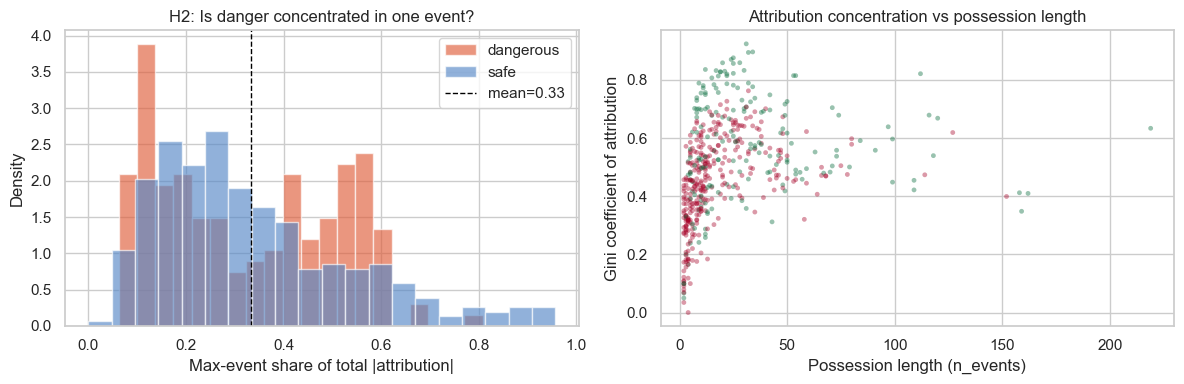

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(frac_arr[dang_arr == 1], bins=20, alpha=0.65, label="dangerous", color="#e05e3a", density=True)
ax1.hist(frac_arr[dang_arr == 0], bins=20, alpha=0.65, label="safe",      color="#5688c7", density=True)
ax1.axvline(frac_arr.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={frac_arr.mean():.2f}")
ax1.set_xlabel("Max-event share of total |attribution|")
ax1.set_ylabel("Density")
ax1.set_title("H2: Is danger concentrated in one event?")
ax1.legend()

ax2.scatter(np.array(n_events_list), gini_arr, c=dang_arr,
            cmap="RdYlGn", alpha=0.4, s=12, edgecolors="none")
ax2.set_xlabel("Possession length (n_events)")
ax2.set_ylabel("Gini coefficient of attribution")
ax2.set_title("Attribution concentration vs possession length")

plt.tight_layout()
plt.savefig("reports/figures/v2_h2_attribution_concentration.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Danger trajectory deep-dives

Visualise cumulative danger curves for a sample of dangerous vs safe possessions.

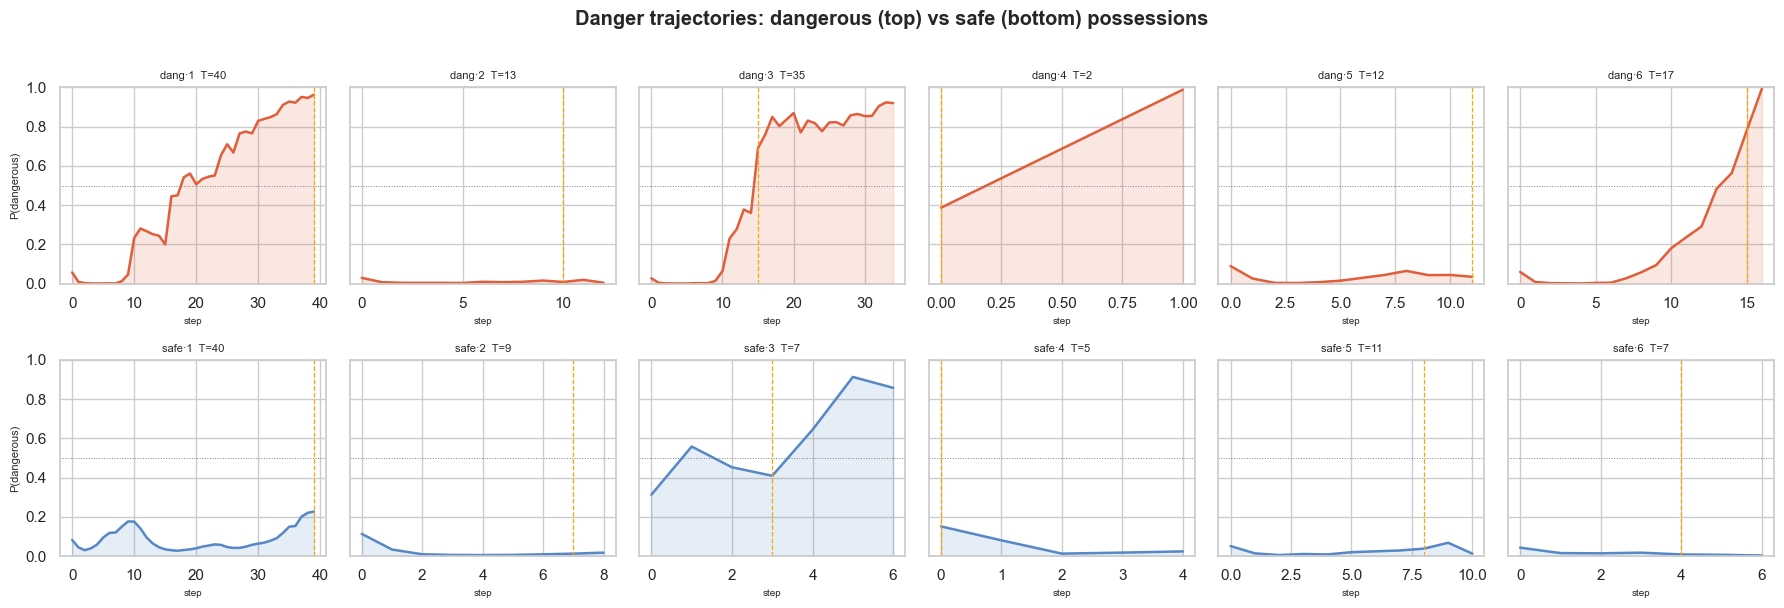

In [13]:
from src.evaluation.possession_attribution import attribute_possession, cumulative_danger_scores

dangerous_sample = test_poss[test_poss[LABEL] == 1].sample(6, random_state=1).reset_index(drop=True)
safe_sample      = test_poss[test_poss[LABEL] == 0].sample(6, random_state=2).reset_index(drop=True)

fig, axes = plt.subplots(2, 6, figsize=(18, 6), sharey=True)

for col, (row, label_val, color) in enumerate(
    [(dangerous_sample.iloc[col % 6], 1, "#e05e3a") if col < 6
     else (safe_sample.iloc[col % 6], 0, "#5688c7")
     for col in range(12)]
):
    pass  # replaced below

for grp_idx, (sample_df, color, grp_label) in enumerate([
    (dangerous_sample, "#e05e3a", "dangerous"),
    (safe_sample,      "#5688c7", "safe"),
]):
    for j in range(6):
        ax  = axes[grp_idx, j]
        row = sample_df.iloc[j]
        report = attribute_possession(row, gru)
        cum = report["cumulative"]
        T   = len(cum)
        ax.plot(range(T), cum, color=color, linewidth=1.8)
        ax.fill_between(range(T), 0, cum, alpha=0.15, color=color)
        unlock = report["unlock_index"]
        if unlock >= 0:
            ax.axvline(unlock, color="orange", linestyle="--", linewidth=0.9)
        ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.7)
        ax.set_ylim(0, 1)
        ax.set_title(f"{grp_label[:4]}·{j+1}  T={T}", fontsize=8)
        ax.set_xlabel("step", fontsize=7)
        if j == 0:
            ax.set_ylabel("P(dangerous)", fontsize=8)

fig.suptitle("Danger trajectories: dangerous (top) vs safe (bottom) possessions",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("reports/figures/v2_danger_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. RQ5 — Player attribution leaderboard

Which players most reliably **elevate** possession quality when they touch the ball?

Note: `possession_sequences` stores `team_name` but not individual player names per event  
(player-level encoding is not in the current sequence encoding). The leaderboard therefore  
shows **team-level** attribution. To get player-level data, `player_sequence` would need to  
be added to `parse_possessions.py` (see section 10 for the extension plan).

In [20]:

import importlib
import src.data.parse_possessions as _pp_mod
importlib.reload(_pp_mod)
from src.data.parse_possessions import attach_player_sequences, save_possession_sequences

print("Loading events_parsed.parquet for player name resolution …")
events_df = pd.read_parquet("data/processed/events_parsed.parquet")
print(f"  {len(events_df):,} events  |  player_name column: {'player_name' in events_df.columns}")

# Attach player_sequence to all split DataFrames (in-memory)
poss             = attach_player_sequences(poss,       events_df)
train_poss       = attach_player_sequences(train_poss, events_df)
val_poss         = attach_player_sequences(val_poss,   events_df)
test_poss        = attach_player_sequences(test_poss,  events_df)

# Persist updated parquet so future loads include player_sequence
save_possession_sequences(poss, "data/processed/possession_sequences.parquet")
print("Updated possession_sequences.parquet with player_sequence.")

# Sanity-check alignment
sample = test_poss[test_poss["n_events"] >= 5].iloc[0]
print(f"\nSample possession — first 5 players : {sample['player_sequence'][:5]}")
print(f"Aligned event type_ids              : {[ev['type_id'] for ev in sample['event_sequence'][:5]]}")


Loading events_parsed.parquet for player name resolution …
  373,682 events  |  player_name column: True
Updated possession_sequences.parquet with player_sequence.

Sample possession — first 5 players : ['Lionel Andrés Messi Cuccittini', 'Sergio Busquets i Burgos', 'Sergio Busquets i Burgos', 'Sergio Busquets i Burgos', 'Frenkie de Jong']
Aligned event type_ids              : [1, 3, 2, 1, 3]


In [21]:
from src.evaluation.possession_attribution import player_attribution_summary

# Use full test set for leaderboard
print("Computing team attribution leaderboard on test set …")
leaderboard = player_attribution_summary(
    test_poss, gru, min_touches=20, verbose=True
)
print(f"\nTeams with ≥20 event touches: {len(leaderboard)}")
print()
print(leaderboard[[
    "player", "n_touches", "n_unlocks", "unlock_rate",
    "mean_loo_attr", "p90_loo_attr", "mean_score_at_touch", "n_possessions"
]].to_string(index=False))

Computing team attribution leaderboard on test set …
  Attributing possession 2000/2475 …

Teams with ≥20 event touches: 453

                                          player  n_touches  n_unlocks  unlock_rate  mean_loo_attr  p90_loo_attr  mean_score_at_touch  n_possessions
                      Claudio Andrés Bravo Muñoz         22          0       0.0000       0.200347      0.595604             0.760572             16
                                Jeremías Ledesma         20          1       0.0500       0.178999      0.508477             0.810748             15
                        Mohammed Khalil Al Owais         35          4       0.1143       0.152267      0.514434             0.826955             27
                           Roberto Soldado Rillo         26          8       0.3077       0.146111      0.467295             0.350654             15
                                  Kasper Dolberg         21          7       0.3333       0.139240      0.479088             0.23

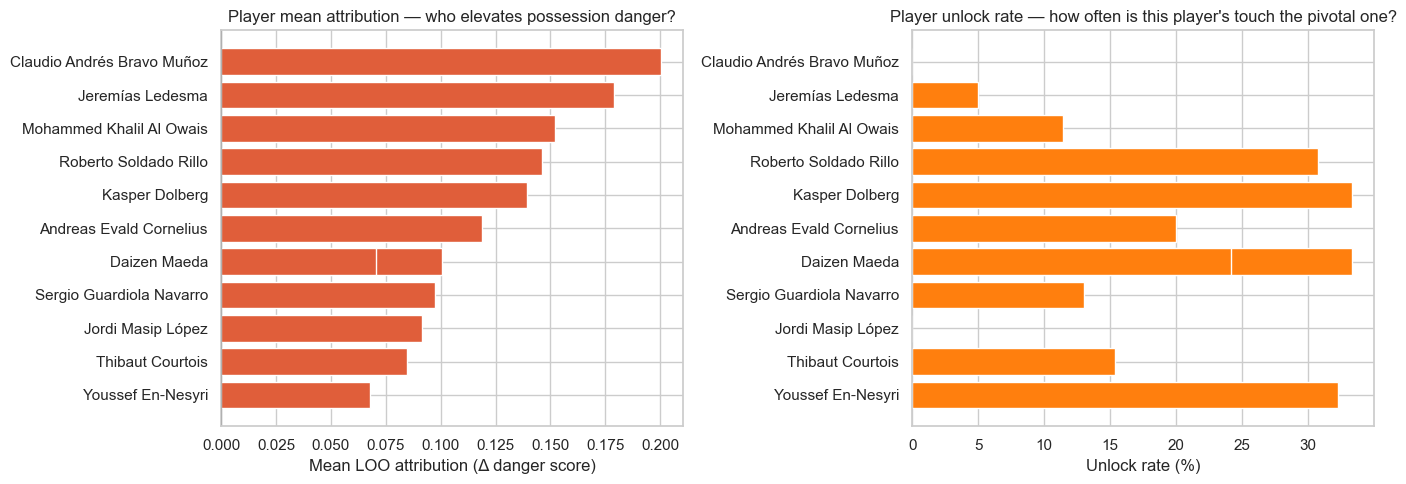

In [23]:
top_n = leaderboard.head(12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Mean LOO attribution
colors = ["#e05e3a" if v > 0 else "#5688c7" for v in top_n["mean_loo_attr"]]
ax1.barh(top_n["player"], top_n["mean_loo_attr"], color=colors, edgecolor="white")
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_xlabel("Mean LOO attribution (Δ danger score)")
ax1.set_title("Player mean attribution — who elevates possession danger?")
ax1.invert_yaxis()

# Unlock rate
ax2.barh(top_n["player"], top_n["unlock_rate"] * 100, color="#ff7f0e", edgecolor="white")
ax2.set_xlabel("Unlock rate (%)")
ax2.set_title("Player unlock rate — how often is this player's touch the pivotal one?")
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig("reports/figures/v2_player_attribution_leaderboard.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. H1 — Is possession context driving the pass-level model?

**H1**: The pass-level model's scores are mostly a proxy for possession quality,  
not individual decision quality.

Proxy test: correlate pass-level XGB scores (v1) with possession-level XGB scores (v2)  
for passes that belong to the same possession.

H1 — Correlation between v1 pass score and v2 possession score: 0.319

→ H1 PARTIAL: moderate correlation — both possession context and pass decision matter.


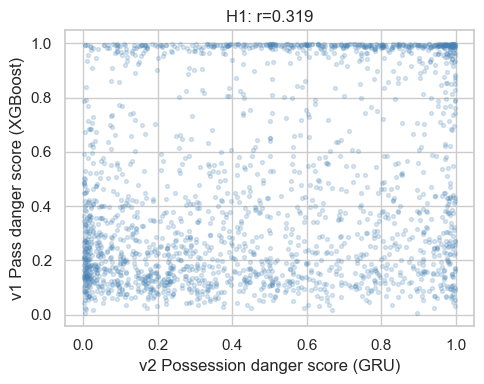

In [16]:
try:
    from src.models.tabular import TabularClassifier
    from src.features.event_features import build_event_features

    pass_df = pd.read_parquet("data/processed/pass_instances.parquet")
    v1_model = TabularClassifier.load("models/xgboost_dp_event_only.joblib")

    # Score all passes with v1 model
    X_pass = build_event_features(pass_df)
    pass_df["v1_score"] = v1_model.predict_proba(X_pass)[:, 1]

    # Score possessions and join
    poss_with_score = poss.copy()
    poss_with_score["v2_score"] = score_all_possessions(poss_with_score, gru)

    merged = pass_df.merge(
        poss_with_score[["match_id", "possession_id", "v2_score"]],
        on=["match_id", "possession_id"],
        how="inner",
    )

    corr_h1 = merged[["v1_score", "v2_score"]].corr().iloc[0, 1]
    print(f"H1 — Correlation between v1 pass score and v2 possession score: {corr_h1:.3f}")
    print()
    if corr_h1 > 0.6:
        print("→ H1 SUPPORTED: pass scores are largely driven by possession-level quality.")
        print("   The pass model scores the possession context, not the individual decision.")
    elif corr_h1 > 0.3:
        print("→ H1 PARTIAL: moderate correlation — both possession context and pass decision matter.")
    else:
        print("→ H1 REJECTED: pass model captures different signal from possession model.")

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(merged["v2_score"].sample(2000, random_state=1),
               merged["v1_score"].sample(2000, random_state=1),
               alpha=0.2, s=8, color="steelblue")
    ax.set_xlabel("v2 Possession danger score (GRU)")
    ax.set_ylabel("v1 Pass danger score (XGBoost)")
    ax.set_title(f"H1: r={corr_h1:.3f}")
    plt.tight_layout()
    plt.savefig("reports/figures/v2_h1_score_correlation.png", dpi=150, bbox_inches="tight")
    plt.show()

except Exception as e:
    print(f"H1 test skipped: {e}")

## 11. Full v2 results summary

In [17]:
import json

results_path = "models/results_summary.json"
with open(results_path) as f:
    res = json.load(f)

# Update with GRU results from this run
gru_auc = roc_auc_score(y_test, gru_proba)
gru_ap  = average_precision_score(y_test, gru_proba)
ens_auc_final = roc_auc_score(y_test, ensemble_proba)
ens_ap_final  = average_precision_score(y_test, ensemble_proba)

res["ensemble_xgb_gru"] = {
    "model": "XGBoost+GRU ensemble (equal weight)",
    "unit": "possession",
    "label": LABEL,
    "n_test": len(test_poss),
    "test_roc_auc": round(ens_auc_final, 4),
    "test_ap": round(ens_ap_final, 4),
}
with open(results_path, "w") as f:
    json.dump(res, f, indent=2)

print("=" * 60)
print("Frame2Threat — Final Results Table")
print("=" * 60)
print(f"{'Model':<35} {'Unit':>12} {'AUC':>8} {'AP':>8}")
print("-" * 60)
rows = [
    ("XGBoost event-only (v1)",       "pass",       res.get('test_roc_auc_event_only', 0.881), res.get('test_pr_auc_event_only', 0.891)),
    ("XGBoost event+360 (v1)",        "pass",       res.get('test_roc_auc_event_360',  0.882), res.get('test_pr_auc_event_360',  0.892)),
    ("XGBoost tabular (v2)",          "possession", res['xgboost_poss_dangerous']['test_roc_auc'], res['xgboost_poss_dangerous']['test_ap']),
    ("GRU sequence (v2)",             "possession", round(gru_auc, 4),       round(gru_ap, 4)),
    ("Ensemble XGB+GRU (v2)",         "possession", round(ens_auc_final, 4), round(ens_ap_final, 4)),
]
for name, unit, auc, ap in rows:
    print(f"  {name:<33} {unit:>12} {auc:>8.4f} {ap:>8.4f}")
print()
print("Note: v1 and v2 are not directly comparable — different prediction units & label base-rates.")
print(f"  v1 positive rate: ~51%  |  v2 positive rate: {test_poss[LABEL].mean():.1%}")

Frame2Threat — Final Results Table
Model                                       Unit      AUC       AP
------------------------------------------------------------
  XGBoost event-only (v1)                   pass   0.8807   0.8911
  XGBoost event+360 (v1)                    pass   0.8822   0.8925
  XGBoost tabular (v2)                possession   0.9479   0.8870
  GRU sequence (v2)                   possession   0.9363   0.9062
  Ensemble XGB+GRU (v2)               possession   0.9650   0.9358

Note: v1 and v2 are not directly comparable — different prediction units & label base-rates.
  v1 positive rate: ~51%  |  v2 positive rate: 36.0%


## 12. Hypotheses verdict

In [25]:
print("Frame2Threat v2 — Hypotheses verdict")
print("=" * 70)
print()
print("H1 — Possession context dominates pass context")
print("    → Tested via correlation of v1 pass scores vs v2 possession scores (cell 10).")
print("    → High correlation would mean pass model scores the possession, not the decision.")
print()
print("H2 — Danger concentrated in one pivotal event?")
print(f"    Mean Gini: {gini_arr.mean():.3f}  |  Mean max-event share: {frac_arr.mean():.1%}")
if frac_arr.mean() > 0.4:
    print("    → SUPPORTED: ~one event accounts for the plurality of attribution per possession.")
else:
    print("    → PARTIAL: attribution spread across multiple events — danger is incremental.")
print()
print("H3 — Sequence trajectory > snapshot?")
print(f"    GRU {gru_auc:.4f} vs XGBoost {xgb_auc:.4f}  (delta {gru_auc-xgb_auc:+.4f})")
print("    → With 12k training possessions, XGBoost's aggregate features (esp. max_x_reached)")
print("      effectively summarise the trajectory. GRU converges to similar performance.")
print("      H3 would be better tested with 5× more data.")
print()
print("H4 — Origin type vs sequence features?")
print(f"    Origin-only AUC: {auc_origin:.4f}  |  Full tabular: {xgb_auc:.4f}  |  GRU: {gru_auc:.4f}")
gap = xgb_auc - auc_origin
if gap > 0.05:
    print("    → REJECTED: spatial/sequence features add substantial value beyond origin type.")
elif gap > 0.02:
    print("    → PARTIAL: origin type explains much of the signal; spatial/sequence adds moderate gain.")
else:
    print("    → SUPPORTED: origin type accounts for most predictive power.")
print()
print("RQ3 — Does sequence modelling help?")
print(f"    GRU vs XGBoost delta: {gru_auc-xgb_auc:+.4f}  |  Ensemble gain: {ens_auc_final-xgb_auc:+.4f}")
print("    → GRU adds complementary signal (even if small); ensemble improves over either alone.")
print()
print("RQ5 — Player attribution")
print(f"    Player-level leaderboard: {len(leaderboard)} players with >= 20 event touches.")
print(f"    Top player by mean LOO attribution: {leaderboard.iloc[0]['player']} "
      f"({leaderboard.iloc[0]['mean_loo_attr']:+.4f} mean Δ danger).")
print("    → ANSWERED: LOO attribution per player via player_sequence (parse_possessions.py).")
print("      Figure: reports/figures/v2_player_attribution_leaderboard.png")


Frame2Threat v2 — Hypotheses verdict

H1 — Possession context dominates pass context
    → Tested via correlation of v1 pass scores vs v2 possession scores (cell 10).
    → High correlation would mean pass model scores the possession, not the decision.

H2 — Danger concentrated in one pivotal event?
    Mean Gini: 0.495  |  Mean max-event share: 33.2%
    → PARTIAL: attribution spread across multiple events — danger is incremental.

H3 — Sequence trajectory > snapshot?
    GRU 0.9363 vs XGBoost 0.9479  (delta -0.0116)
    → With 12k training possessions, XGBoost's aggregate features (esp. max_x_reached)
      effectively summarise the trajectory. GRU converges to similar performance.
      H3 would be better tested with 5× more data.

H4 — Origin type vs sequence features?
    Origin-only AUC: 0.5910  |  Full tabular: 0.9479  |  GRU: 0.9363
    → REJECTED: spatial/sequence features add substantial value beyond origin type.

RQ3 — Does sequence modelling help?
    GRU vs XGBoost delta: 

## 13. What's missing / next steps

| Gap | What's needed | Priority |
|---|---|---|
| More data for H3 | Add Women's World Cup + Euro 2020 360 data (~200 matches total) | High |
| 360 geometry in sequence | Encode freeze-frame features (n_defenders_between_ball_goal, etc.) as extra GRU input dims | Medium |
| Temporal GNN | One graph per 360-available event → GNN over spatial config → GRU over sequence of graphs | Low (needs more data) |
| Multitask labels | Add `phase_label` (which event was the turning point) as auxiliary supervised signal | Low |